# Notebook 03: Abstractive Model (Phase 1.3)

## Mục tiêu
- Test Abstractive Model với ViT5
- So sánh Hybrid (Extract → Abstract) vs Direct Abstractive
- Test generation parameters
- Evaluate quality

## Phase 1.3: Abstractive Model

**Cơ chế:**
1. Load ViT5 model (Vietnamese T5)
2. Preprocess input (remove underscores for ViT5)
3. Generate summary với beam search
4. Support 2 approaches:
   - **Hybrid**: Extract sentences → Abstract
   - **Direct**: Full document → Abstract


In [1]:
# Setup
import sys
import os

sys.path.append(os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Import our modules
from data_loader import VietNewsDataset
from preprocessor import VietnamesePreprocessor
from extractive import ExtractiveModel
from abstractive import AbstractiveModel

# Config
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")


✓ Imports successful


## 1. Load Data


In [2]:
# Load dataset
dataset = VietNewsDataset(data_dir='../data')
val_data = dataset.load_split('validation', dataset_name='partial_dataset')

print(f"\nValidation set: {len(val_data)} samples")
print(f"Sample keys: {val_data[0].keys()}")


Loading dataset 'partial_dataset' first...
Loaded dataset from partial_dataset:
  Train: 1000 samples
  Validation: 200 samples
  Test: 200 samples
Loaded 200 samples from validation split

Validation set: 200 samples
Sample keys: dict_keys(['article', 'summary', 'title', 'guid'])


## 2. Initialize Models


In [7]:
# Initialize Extractive Model (Phase 1.2)
print("Loading Extractive Model...")
extractor = ExtractiveModel(model_name="vinai/phobert-base")

print("\nLoading Abstractive Model...")
abstractor = AbstractiveModel(model_name="VietAI/vit5-base-vietnews-summarization")

print("\n✓ Both models loaded successfully")


Loading Extractive Model...
Loading vinai/phobert-base on cpu...
✓ Model loaded successfully on cpu

Loading Abstractive Model...
Loading VietAI/vit5-base-vietnews-summarization on cpu...
✓ Model loaded successfully on cpu
  Max input length: 512 tokens
  Output length: 20-128 tokens

✓ Both models loaded successfully


## 3. Test trên 1 Sample

### 3.1 Visualize Document


In [4]:
# Chọn 1 sample
sample_idx = 0
sample = val_data[sample_idx]

print("="*80)
print("SAMPLE DOCUMENT")
print("="*80)
print(f"\nArticle ({len(sample['article'])} chars):")
print(sample['article'])
print(f"\n{'-'*80}")
print(f"\nReference Summary ({len(sample['summary'])} chars):")
print(sample['summary'])
print("\n" + "="*80)


SAMPLE DOCUMENT

Article (3579 chars):
Ngày 22/6 , cơ_quan CSĐT Công_an T X.Phú Mỹ đã ra quyết_định khởi_tố vụ án hình_sự về các tội Gây_rối trật_tự công_cộng và Cố_ý làm hư_hỏng tài_sản ; ra quyết_định khởi_tố bị_can , lệnh tạm giam đối_với Nguyễn_Huỳnh_Tú_Trinh , Trần_Quốc_Tĩnh về tội Cố_ý làm hư_hỏng tài_sản và chuyển toàn_bộ hồ_sơ vụ án đến VKSND cùng cấp đề_nghị phê_chuẩn . Cùng ngày , VKSND_T X.Phú Mỹ cũng phê_chuẩn quyết_định khởi_tố bị_can , lệnh tạm giam đối_với Nguyễn_Huỳnh_Tú_Trinh , Trần_Quốc_Tĩnh về hành_vi cố_ý làm hư_hỏng tài_sản . Theo hồ_sơ điều_tra ban_đầu , sáng 13/6 , UBND xã Tóc_Tiên phối_hợp với các cơ_quan_chức_năng tiến_hành cưỡng_chế hành_chính bắt_buộc , thực_hiện biện_pháp khắc_phục hậu_quả đối_với hành_vi thay_đổi hiện_trạng mục_đích sử_dụng đất ( làm đường trái_phép ) trên đất nông_nghiệp tại các thửa đất số : 133 , 139 , 248 , 249 tờ bản_đồ số 17 , địa_chỉ thửa đất tại ấp 3 , xã Tóc_Tiên . Khu đất này do ông Nguyễn_Thế_Lực ( 20 tuổi , trú tại TP. HCM ) làm

### 3.2 Approach 1: Extractive Only


In [5]:
# Step 1: Extract important sentences
result = extractor.rank_sentences(
    document=sample['article'],
    k=3,
    strategy='mmr',
    use_position_weights=False
)

extractive_sentences = result['sentences_original']
extractive_summary = ' '.join(extractive_sentences)

print("="*80)
print("APPROACH 1: EXTRACTIVE ONLY")
print("="*80)

print("\nExtracted sentences:")
for i, (sent, score, idx) in enumerate(zip(
    result['sentences_original'],
    result['scores'],
    result['indices']
), 1):
    print(f"\n{i}. [Sentence #{idx}, Score: {score:.4f}]")
    print(f"   {sent}")

print("\n" + "-"*80)
print("📝 Extractive Summary:")
print("-"*80)
print(extractive_summary)
print(f"\nLength: {len(extractive_summary)} chars")


Encoding 19 sentences...
APPROACH 1: EXTRACTIVE ONLY

Extracted sentences:

1. [Sentence #10, Score: 0.8775]
   Sau đó , đoàn cưỡng_chế yêu_cầu đám đông những người mặc áo có in dòng chữ Tập_đoàn địa_ốc Alibaba đang tập_trung giải_tán , không cản_trở đoàn tháo_dỡ xây_dựng công_trình trái_phép thì những người trên tiếp_tục hò_hét , kích_động nhau cùng cản_trở , chống_đối .

2. [Sentence #13, Score: 0.3866]
   Riêng đối_với Nguyễn_Huỳnh_Tú_Trinh , thừa_nhận đã hành_vi đã chỉ_đạo , kêu người đến đập xe_máy múc , nhưng cho_rằng đó là bảo_vệ tài_sản công_dân .

3. [Sentence #15, Score: 0.3998]
   Theo VKSND thị_xã Phú_Mỹ , cơ_quan CSĐT Công_an thị_xã Phú_Mỹ áp_dụng biện_pháp ngăn_chặn tạm giam đối_với Nguyễn_Huỳnh_Tú_Trinh , Trần_Quốc_Tĩnh là cần_thiết và đúng quy_định của pháp_luật .

--------------------------------------------------------------------------------
📝 Extractive Summary:
--------------------------------------------------------------------------------
Sau đó , đoàn cưỡng_chế 

### 3.3 Approach 2: Hybrid (Extract → Abstract)


In [8]:
# Step 2: Generate abstractive summary from extractive sentences
print("="*80)
print("APPROACH 2: HYBRID (Extract → Abstract)")
print("="*80)

print("\nGenerating abstractive summary from extractive sentences...")

hybrid_summary = abstractor.generate_from_extractive(
    extractive_sentences,
    num_beams=4,
    length_penalty=1.0
)

print("\n📝 Hybrid Summary (Extractive → Abstractive):")
print("-"*80)
print(hybrid_summary)
print(f"\nLength: {len(hybrid_summary)} chars")


APPROACH 2: HYBRID (Extract → Abstract)

Generating abstractive summary from extractive sentences...

📝 Hybrid Summary (Extractive → Abstractive):
--------------------------------------------------------------------------------
Chiều 23-3 , Viện KSND thị xã Phú Mỹ ( Bà Rịa - Vũng Tàu ) đã ra quyết định khởi tố vụ án , khởi tố bị can , bắt tạm giam Trần Quốc Tĩnh , 3 tháng về tội " cố ý gây thương tích " .

Length: 180 chars


### 3.4 Approach 3: Direct Abstractive


In [9]:
# Direct: Full document → Abstractive
print("="*80)
print("APPROACH 3: DIRECT ABSTRACTIVE")
print("="*80)

print("\nGenerating abstractive summary from full document...")

direct_summary = abstractor.generate_from_document(
    sample['article'],
    num_beams=4
)

print("\n📝 Direct Abstractive Summary:")
print("-"*80)
print(direct_summary)
print(f"\nLength: {len(direct_summary)} chars")


APPROACH 3: DIRECT ABSTRACTIVE

Generating abstractive summary from full document...

📝 Direct Abstractive Summary:
--------------------------------------------------------------------------------
Cơ quan CSĐT Công an T X.Phú Mỹ , tỉnh Bà Rịa  Vũng Tàu ra quyết định khởi tố vụ án hình sự về các tội Gây rối trật tự công cộng và Cố ý làm hư hỏng tài sản ; khởi tố bị can , tạm giam đối với một số nhân viên công ty Địa ốc Alibaba .

Length: 234 chars


### 3.5 Compare All Approaches


In [10]:
print("="*80)
print("COMPARISON: ALL APPROACHES")
print("="*80)

print("\n1. Reference Summary (Ground Truth):")
print("-"*80)
print(sample['summary'])
print(f"Length: {len(sample['summary'])} chars")

print("\n2. Extractive Only:")
print("-"*80)
print(extractive_summary)
print(f"Length: {len(extractive_summary)} chars")

print("\n3. Hybrid (Extract → Abstract):")
print("-"*80)
print(hybrid_summary)
print(f"Length: {len(hybrid_summary)} chars")

print("\n4. Direct Abstractive:")
print("-"*80)
print(direct_summary)
print(f"Length: {len(direct_summary)} chars")

print("\n" + "="*80)


COMPARISON: ALL APPROACHES

1. Reference Summary (Ground Truth):
--------------------------------------------------------------------------------
Viện_kiểm_sát nhân_dân T X.Phú Mỹ , tỉnh Bà_Rịa – Vũng_Tàu vừa phê_chuẩn quyết_định khởi_tố bị_can , lệnh tạm giam đối_với 2 nhân_viên công_ty Địa_ốc Alibaba là Nguyễn_Huỳnh_Tú_Trinh và Trần_Quốc_Tĩnh về hành_vi cố_ý làm hư_hỏng tài_sản .
Length: 238 chars

2. Extractive Only:
--------------------------------------------------------------------------------
Sau đó , đoàn cưỡng_chế yêu_cầu đám đông những người mặc áo có in dòng chữ Tập_đoàn địa_ốc Alibaba đang tập_trung giải_tán , không cản_trở đoàn tháo_dỡ xây_dựng công_trình trái_phép thì những người trên tiếp_tục hò_hét , kích_động nhau cùng cản_trở , chống_đối . Riêng đối_với Nguyễn_Huỳnh_Tú_Trinh , thừa_nhận đã hành_vi đã chỉ_đạo , kêu người đến đập xe_máy múc , nhưng cho_rằng đó là bảo_vệ tài_sản công_dân . Theo VKSND thị_xã Phú_Mỹ , cơ_quan CSĐT Công_an thị_xã Phú_Mỹ áp_dụng biện_pháp ng

## 4. Test Generation Parameters

### 4.1 Different num_beams


In [11]:
print("="*80)
print("TEST: DIFFERENT NUM_BEAMS")
print("="*80)

for num_beams in [2, 4, 6]:
    summary = abstractor.generate_from_extractive(
        extractive_sentences,
        num_beams=num_beams
    )
    
    print(f"\nnum_beams={num_beams}:")
    print("-"*80)
    print(summary)


TEST: DIFFERENT NUM_BEAMS

num_beams=2:
--------------------------------------------------------------------------------
Chiều 23-3 , Viện KSND thị xã Phú Mỹ ( Bà Rịa - Vũng Tàu ) đã ra quyết định khởi tố vụ án , khởi tố bị can , bắt tạm giam Trần Quốc Tĩnh , 3 tháng về tội " cố ý gây thương tích " .

num_beams=4:
--------------------------------------------------------------------------------
Chiều 23-3 , Viện KSND thị xã Phú Mỹ ( Bà Rịa - Vũng Tàu ) đã ra quyết định khởi tố vụ án , khởi tố bị can , bắt tạm giam Trần Quốc Tĩnh , 3 tháng về tội " cố ý gây thương tích " .

num_beams=6:
--------------------------------------------------------------------------------
Chiều 23-3 , Viện KSND thị xã Phú Mỹ ( Bà Rịa - Vũng Tàu ) đã ra quyết định khởi tố vụ án , khởi tố bị can , bắt tạm giam Trần Quốc Tĩnh , 3 tháng về tội " cố ý gây thương tích " .


### 4.2 Different length_penalty


In [12]:
print("="*80)
print("TEST: DIFFERENT LENGTH_PENALTY")
print("="*80)

for penalty in [0.8, 1.0, 1.2]:
    summary = abstractor.generate_from_extractive(
        extractive_sentences,
        num_beams=4,
        length_penalty=penalty
    )
    
    print(f"\nlength_penalty={penalty}:")
    print("-"*80)
    print(summary)
    print(f"Length: {len(summary)} chars")


TEST: DIFFERENT LENGTH_PENALTY

length_penalty=0.8:
--------------------------------------------------------------------------------
Chiều 23-3 , Viện KSND thị xã Phú Mỹ ( Bà Rịa - Vũng Tàu ) đã ra quyết định khởi tố vụ án , khởi tố bị can , bắt tạm giam Trần Quốc Tĩnh , 3 tháng về tội " cố ý gây thương tích " .
Length: 180 chars

length_penalty=1.0:
--------------------------------------------------------------------------------
Chiều 23-3 , Viện KSND thị xã Phú Mỹ ( Bà Rịa - Vũng Tàu ) đã ra quyết định khởi tố vụ án , khởi tố bị can , bắt tạm giam Trần Quốc Tĩnh , 3 tháng về tội " cố ý gây thương tích " .
Length: 180 chars

length_penalty=1.2:
--------------------------------------------------------------------------------
Chiều 23-3 , Viện KSND thị xã Phú Mỹ ( Bà Rịa - Vũng Tàu ) đã ra quyết định khởi tố vụ án , khởi tố bị can , bắt tạm giam Trần Quốc Tĩnh , 3 tháng về tội " cố ý gây thương tích " .
Length: 180 chars


## 5. Test trên Multiple Samples


In [13]:
# Test trên 5 samples
n_samples = 5
test_samples = val_data[:n_samples]

results = []

print(f"Testing on {n_samples} samples...\n")

for i, sample in enumerate(tqdm(test_samples, desc="Processing")):
    # Extract
    result = extractor.rank_sentences(
        sample['article'],
        k=3,
        strategy='mmr',
        use_position_weights=False
    )
    extractive_sents = result['sentences_original']
    extractive_sum = ' '.join(extractive_sents)
    
    # Hybrid
    hybrid_sum = abstractor.generate_from_extractive(
        extractive_sents,
        num_beams=4
    )
    
    # Direct
    direct_sum = abstractor.generate_from_document(
        sample['article'],
        num_beams=4
    )
    
    results.append({
        'sample_id': i,
        'reference': sample['summary'],
        'extractive': extractive_sum,
        'hybrid': hybrid_sum,
        'direct': direct_sum,
        'ref_len': len(sample['summary']),
        'ext_len': len(extractive_sum),
        'hyb_len': len(hybrid_sum),
        'dir_len': len(direct_sum)
    })

print("\n✓ Testing complete")


Testing on 5 samples...



Processing:   0%|          | 0/5 [00:00<?, ?it/s]

Encoding 19 sentences...
Encoding 20 sentences...
Encoding 18 sentences...
Encoding 15 sentences...
Encoding 16 sentences...

✓ Testing complete


In [14]:
# Analyze results
df_results = pd.DataFrame([{
    'Sample': r['sample_id'],
    'Ref_Len': r['ref_len'],
    'Ext_Len': r['ext_len'],
    'Hyb_Len': r['hyb_len'],
    'Dir_Len': r['dir_len']
} for r in results])

print("="*80)
print("LENGTH COMPARISON")
print("="*80)
print(df_results)
print("\n" + "="*80)
print("STATISTICS")
print("="*80)
print(df_results.describe())


LENGTH COMPARISON
   Sample  Ref_Len  Ext_Len  Hyb_Len  Dir_Len
0       0      238      604      180      234
1       1      187      190      136      164
2       2      173      346      187      118
3       3      138      220      189      149
4       4      165      334      189      167

STATISTICS
         Sample     Ref_Len     Ext_Len     Hyb_Len     Dir_Len
count  5.000000    5.000000    5.000000    5.000000    5.000000
mean   2.000000  180.200000  338.800000  176.200000  166.400000
std    1.581139   36.914767  163.294825   22.774986   42.488822
min    0.000000  138.000000  190.000000  136.000000  118.000000
25%    1.000000  165.000000  220.000000  180.000000  149.000000
50%    2.000000  173.000000  334.000000  187.000000  164.000000
75%    3.000000  187.000000  346.000000  189.000000  167.000000
max    4.000000  238.000000  604.000000  189.000000  234.000000


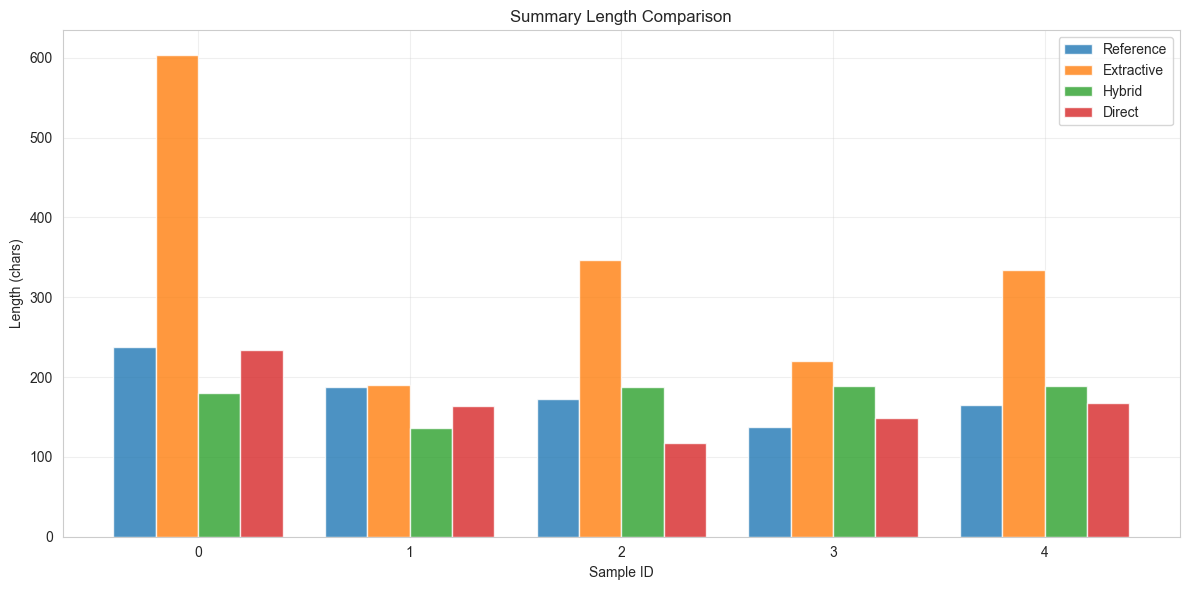

In [15]:
# Visualize lengths
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_results))
width = 0.2

ax.bar(x - 1.5*width, df_results['Ref_Len'], width, label='Reference', alpha=0.8)
ax.bar(x - 0.5*width, df_results['Ext_Len'], width, label='Extractive', alpha=0.8)
ax.bar(x + 0.5*width, df_results['Hyb_Len'], width, label='Hybrid', alpha=0.8)
ax.bar(x + 1.5*width, df_results['Dir_Len'], width, label='Direct', alpha=0.8)

ax.set_xlabel('Sample ID')
ax.set_ylabel('Length (chars)')
ax.set_title('Summary Length Comparison')
ax.set_xticks(x)
ax.set_xticklabels(df_results['Sample'])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Show Examples


In [16]:
# Show detailed example
example_id = 0
example = results[example_id]

print("="*80)
print(f"EXAMPLE {example_id}")
print("="*80)

print("\nReference:")
print(example['reference'])

print("\nExtractive:")
print(example['extractive'])

print("\nHybrid (Extract → Abstract):")
print(example['hybrid'])

print("\nDirect Abstractive:")
print(example['direct'])

print("\n" + "="*80)


EXAMPLE 0

Reference:
Viện_kiểm_sát nhân_dân T X.Phú Mỹ , tỉnh Bà_Rịa – Vũng_Tàu vừa phê_chuẩn quyết_định khởi_tố bị_can , lệnh tạm giam đối_với 2 nhân_viên công_ty Địa_ốc Alibaba là Nguyễn_Huỳnh_Tú_Trinh và Trần_Quốc_Tĩnh về hành_vi cố_ý làm hư_hỏng tài_sản .

Extractive:
Sau đó , đoàn cưỡng_chế yêu_cầu đám đông những người mặc áo có in dòng chữ Tập_đoàn địa_ốc Alibaba đang tập_trung giải_tán , không cản_trở đoàn tháo_dỡ xây_dựng công_trình trái_phép thì những người trên tiếp_tục hò_hét , kích_động nhau cùng cản_trở , chống_đối . Riêng đối_với Nguyễn_Huỳnh_Tú_Trinh , thừa_nhận đã hành_vi đã chỉ_đạo , kêu người đến đập xe_máy múc , nhưng cho_rằng đó là bảo_vệ tài_sản công_dân . Theo VKSND thị_xã Phú_Mỹ , cơ_quan CSĐT Công_an thị_xã Phú_Mỹ áp_dụng biện_pháp ngăn_chặn tạm giam đối_với Nguyễn_Huỳnh_Tú_Trinh , Trần_Quốc_Tĩnh là cần_thiết và đúng quy_định của pháp_luật .

Hybrid (Extract → Abstract):
Chiều 23-3 , Viện KSND thị xã Phú Mỹ ( Bà Rịa - Vũng Tàu ) đã ra quyết định khởi tố vụ án ,

## 7. Summary & Key Findings

### Deliverables (Phase 1.3):
✅ Abstractive Model hoạt động với ViT5  
✅ **Hybrid approach**: Extract → Abstract  
✅ **Direct approach**: Document → Abstract  
✅ Configurable generation parameters  
✅ Vietnamese preprocessing (no underscore)  

### Key Observations:
1. **Hybrid approach**: Better focus (uses top sentences from extractive)
2. **Direct approach**: May miss important details (truncation if too long)
3. **Generation quality**: Depends on num_beams and length_penalty
4. **Length**: Hybrid tends to be more concise than extractive

### Recommendations:
**Default configuration:**
```python
# Step 1: Extract (MMR)
extractor.rank_sentences(document, k=3, strategy='mmr')

# Step 2: Abstract
abstractor.generate_from_extractive(
    sentences,
    num_beams=4,
    length_penalty=1.0
)
```

### Next Steps:
- Phase 1.4: Vietnamese Evaluator (ROUGE + BERTScore)
- Quantitative evaluation of all approaches
- Compare with reference summaries
